In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader,ConcatDataset
from LSTM_databuilder import AssistSequenceDataset
from LSTM_model_train import AssistLSTM
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import optuna

ROOT = Path(r"C:\Users\loy49\Desktop\REPO\LSTM_HRC")

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
    
from data_proc_2d.app.build_norm_dataset import NormDatasetBuilder


In [2]:
#device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### hyper param short epoch test

In [3]:
# #training config
# epochs = 60
# batch_size = 32
# lr = 3e-4

# #sliding window config
# window_size = 160
# stride = 30
# predict_offset = 0
# num_workers = 4

# mode = "seq2one"  # "seq2one" or "seq2seq"

# hidden_layer = 64

# train_shuffle = False


### hyper param optimization

In [3]:
#training config
epochs = 200
batch_size = 32
lr = 3e-4

#sliding window config
window_size = 160
stride = 30
predict_offset = 0
num_workers = 4

mode = "seq2one"  # "seq2one" or "seq2seq"

hidden_layer = 64

train_shuffle = False

weight_decay = 1e-4

dropout = 0.0
num_layers = 1

# Optuna config
optuna_trials = 30
optuna_epochs = 25

## load training data

In [ ]:
npz_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_02\train\norm"
npz_paths = [os.path.join(npz_dir, f) for f in os.listdir(npz_dir) if f.endswith(".npz")]
datasets = []
print(len(npz_paths))

73


## load norm.npz

In [ ]:

norm_stats = np.load(r"C:\Users\loy49\Desktop\REPO\LSTM_HRC\data_proc_3d\dataset\norm_2026-09-20.npz", allow_pickle=True)  

## load & norm val data

In [ ]:
val_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_02\val\norm"
val_paths = [os.path.join(val_dir, f) for f in os.listdir(val_dir) if f.endswith(".pt")]

npz_val_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_02\val\norm"

In [7]:
if len(os.listdir(npz_val_dir)) <=1:

    builder = NormDatasetBuilder(norm_stats)

    #norm val dataset
    for val_path in val_paths:
        out_path = os.path.join(npz_val_dir, os.path.basename(val_path).replace(".pt", "_norm.npz"))
        builder.build_dataset(val_path,out_path)
    print("Validation dataset normalization complete.")

In [8]:

npz_val_paths = [os.path.join(npz_val_dir, f) for f in os.listdir(npz_val_dir) if f.endswith(".npz")]
print(len(npz_val_paths))

9


## load & norm test data

In [ ]:
test_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_02\test\raw"
test_paths = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith(".pt")]

npz_test_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_02\test\norm"

In [10]:
if len(os.listdir(npz_test_dir)) <=1:
    builder = NormDatasetBuilder(norm_stats)

    #norm test dataset
    for test_path in test_paths:
        out_path = os.path.join(npz_test_dir, os.path.basename(test_path).replace(".pt", "_norm.npz"))
        builder.build_dataset(test_path,out_path)
    print("Test dataset normalization complete.")

    
npz_test_paths = [os.path.join(npz_test_dir, f) for f in os.listdir(npz_test_dir) if f.endswith(".npz")]
print(len(npz_test_paths))

9


In [11]:
FEATURE_KEYS = [
    'joint_speed', 
    'joint_acceleration', 
    'joint_velocity_x', 
    'joint_velocity_y', 
    'joint_velocity_z', 
    'joint_acceleration_x', 
    'joint_acceleration_y', 
    'joint_acceleration_z', 
    'position_x_relative_to_pelvis', 
    'position_y_relative_to_pelvis', 
    'position_z_relative_to_pelvis', 
    'polar_azimuth', 
    'polar_elevation', 
    'joint_angles', 
    'ratios', 
    'distance_from_center'
]

# Change the selected features here!!

In [ ]:
x_keys = [
         'distance_from_center',
         'position_x_relative_to_pelvis', 
         'position_y_relative_to_pelvis', 
         'position_z_relative_to_pelvis', 
         'joint_angles', 
         'polar_elevation'
        ]

## training dataset

In [13]:
for npz_path in npz_paths:
    print(f"Loading dataset from {npz_path}...")
    dataset = AssistSequenceDataset(npz_path=npz_path,
                                    window_size=window_size,
                                    stride=stride,
                                    predict_offset=predict_offset,
                                    mode= mode,
                                    feature_keys=x_keys)
    datasets.append(dataset)

loader = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=train_shuffle, num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)
for x, y in loader:
    step = y["step"]
    progress = y["progress"]
    print("Batch X shape:", x.shape)  # should be [batch_size, window_size, feature_dim]
    print("Batch Y-step shape:", step.shape)  # should be [batch_size]
    print("Batch Y-progress shape:", progress.shape)  # should be [batch_size]
    break

Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\train\norm\features__cam-04_uid-01_take-01_seg-00_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\train\norm\features__cam-04_uid-01_take-01_seg-01_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\train\norm\features__cam-04_uid-01_take-01_seg-03_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\train\norm\features__cam-04_uid-01_take-01_seg-05_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\train\norm\features__cam-04_uid-01_take-01_seg-06_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\train\norm\f

## val dataset

In [14]:
val_datasets = []
for npz_val_path in npz_val_paths:
    print(f"Loading validation dataset from {npz_val_path}...")
    val_dataset = AssistSequenceDataset(npz_path=npz_val_path,
                                        window_size=window_size,
                                        stride=stride,
                                        predict_offset=predict_offset,
                                        mode=mode,
                                        feature_keys=x_keys)
    val_datasets.append(val_dataset)    

val_loader = DataLoader(ConcatDataset(val_datasets), batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)

Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\val\norm\features__cam-04_uid-09_take-02_seg-03_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\val\norm\features__cam-04_uid-01_take-01_seg-02_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\val\norm\features__cam-04_uid-06_take-01_seg-01_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\val\norm\features__cam-04_uid-07_take-01_seg-09_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\val\norm\features__cam-04_uid-07_take-02_seg-01_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKuc

## test dataset

In [15]:
test_datasets = []
for npz_test_path in npz_test_paths:
    print(f"Loading test dataset from {npz_test_path}...")
    test_dataset = AssistSequenceDataset(npz_path=npz_test_path,
                                         window_size=window_size,
                                         stride=stride,
                                         predict_offset=predict_offset,
                                         mode=mode,
                                         feature_keys=x_keys)
    test_datasets.append(test_dataset)    

test_loader = DataLoader(ConcatDataset(test_datasets), batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)

Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\test\norm\features__cam-04_uid-01_take-01_seg-04_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\test\norm\features__cam-04_uid-05_take-01_seg-06_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\test\norm\features__cam-04_uid-06_take-01_seg-02_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\test\norm\features__cam-04_uid-06_take-01_seg-09_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\test\norm\features__cam-04_uid-07_take-02_seg-02_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Video

### model

In [ ]:
# get one batch to infer feature_dim and num_types
x_sample, y_sample = next(iter(loader))

input_dim = x_sample.shape[-1]
num_steps = max(int(d.step.max()) for d in datasets + val_datasets) + 1

print("Input dim:", input_dim)
print("Num steps:", num_steps)
print("X shape:", x_sample.shape)
print("Step shape:", y_sample["step"].shape)
print("Step values:", y_sample["step"].unique())
print("Progress shape:", y_sample["progress"].shape)
print("Progress values:", y_sample["progress"].unique())

num_mistakes = 2
print("Mistake values:", y_sample["mistake"].unique())


## Optuna hyperparameter search

In [ ]:
def objective(trial):
    trial_hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 128])
    trial_num_layers = trial.suggest_int("num_layers", 1, 2)
    trial_dropout = trial.suggest_float("dropout", 0.0, 0.5, step=0.1)
    trial_lr = trial.suggest_float("lr", 1e-5, 3e-3, log=True)
    trial_weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    trial_batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    trial_loader = DataLoader(
        ConcatDataset(datasets), batch_size=trial_batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False
    )
    trial_val_loader = DataLoader(
        ConcatDataset(val_datasets), batch_size=trial_batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False
    )

    trial_model = AssistLSTM(
        input_dim=input_dim, hidden_dim=trial_hidden_dim, num_steps=num_steps,
        dropout=trial_dropout, num_layers=trial_num_layers, num_mistakes=num_mistakes
    ).to(device)
    trial_optimizer = optim.Adam(
        trial_model.parameters(), lr=trial_lr, weight_decay=trial_weight_decay
    )
    trial_ce_loss = nn.CrossEntropyLoss()
    trial_mse_loss = nn.MSELoss()
    best_trial_val_loss = float("inf")

    for epoch in range(optuna_epochs):
        trial_model.train()
        for x, y in trial_loader:
            x = x.to(device)
            y_step = y["step"].to(device)
            y_progress = y["progress"].to(device)
            y_mistake = y["mistake"].to(device)

            trial_optimizer.zero_grad()
            step_pred, progress_pred, mistake_pred = trial_model(x)
            loss = trial_ce_loss(step_pred, y_step) + trial_mse_loss(progress_pred, y_progress) + trial_ce_loss(mistake_pred, y_mistake)
            loss.backward()
            trial_optimizer.step()

        trial_model.eval()
        val_loss_sum = 0.0
        val_sample_count = 0
        with torch.no_grad():
            for x, y in trial_val_loader:
                x = x.to(device)
                y_step = y["step"].to(device)
                y_progress = y["progress"].to(device)
                y_mistake = y["mistake"].to(device)
                step_pred, progress_pred, mistake_pred = trial_model(x)
                loss = trial_ce_loss(step_pred, y_step) + trial_mse_loss(progress_pred, y_progress) + trial_ce_loss(mistake_pred, y_mistake)
                current_batch_size = x.size(0)
                val_loss_sum += loss.item() * current_batch_size
                val_sample_count += current_batch_size

        val_loss = val_loss_sum / val_sample_count
        best_trial_val_loss = min(best_trial_val_loss, val_loss)
        trial.report(val_loss, step=epoch)
        if trial.should_prune():
            del trial_model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            raise optuna.TrialPruned()

    del trial_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return best_trial_val_loss


study = optuna.create_study(
    study_name="assist_lstm_hpo_three_heads",
    storage="sqlite:///assist_lstm_optuna.db",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
    load_if_exists=True,
)
study.optimize(objective, n_trials=optuna_trials, gc_after_trial=True)

In [ ]:
study = optuna.create_study(
    study_name="assist_lstm_hpo_three_heads",
    storage="sqlite:///assist_lstm_optuna.db",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
    load_if_exists=True,
)
print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)

# Reuse the best parameters in the original training and saving pipeline below.
hidden_layer = study.best_params["hidden_dim"]
num_layers = study.best_params["num_layers"]
dropout = study.best_params["dropout"]
lr = study.best_params["lr"]
weight_decay = study.best_params["weight_decay"]
batch_size = study.best_params["batch_size"]

loader = DataLoader(
    ConcatDataset(datasets), batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=(device.type == "cuda"), drop_last=False
)
val_loader = DataLoader(
    ConcatDataset(val_datasets), batch_size=batch_size, shuffle=False, num_workers=num_workers,
    pin_memory=(device.type == "cuda"), drop_last=False
)
test_loader = DataLoader(
    ConcatDataset(test_datasets), batch_size=batch_size, shuffle=False, num_workers=num_workers,
    pin_memory=(device.type == "cuda"), drop_last=False
)

model = AssistLSTM(
    input_dim=input_dim,
    hidden_dim=hidden_layer,
    num_steps=num_steps,
    dropout=dropout,
    num_layers=num_layers,
    num_mistakes=num_mistakes
).to(device)


In [18]:
x_val_sample, y_val_sample = next(iter(val_loader))
print("progress value", y_val_sample["progress"].unique())
print("step value", y_val_sample["step"].unique())

progress value tensor([0.0000, 0.1566, 0.2020, 0.2449, 0.2821, 0.3105, 0.3271, 0.3300, 0.3432,
        0.3644, 0.4010, 0.4479, 0.5000, 0.5521, 0.5990, 0.6356, 0.6568, 0.6600,
        0.6704, 0.6956, 0.7504, 0.8213, 0.8947, 0.9570, 0.9947])
step value tensor([2, 5])


In [ ]:

optimizer = optim.Adam(model.parameters(), lr=lr,weight_decay=weight_decay)

ce_loss = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

#should adjust later
lambda_step = 1.0
lambda_progress = 1.0
lambda_mistake = 1.0


In [ ]:
config = {
    "feature_keys": x_keys,
    "normalize": True,
    "window_size": window_size,
    "stride": stride,
    "predict_offset": predict_offset,
    "mode": mode,

    "model": "LSTM",
    "input_dim": input_dim,
    "hidden_dim": hidden_layer,
    "num_steps": num_steps,
    "num_mistakes": num_mistakes,
    "num_layers": num_layers,

    "epochs": epochs,
    "batch_size": batch_size,
    "learning_rate": lr,
    "lambda_step": lambda_step,
    "lambda_progress": lambda_progress,
    "lambda_mistake": lambda_mistake,

    "training_shuffle": train_shuffle,

    "weight_decay": weight_decay,

    "dropout": dropout

}

In [21]:
config

{'feature_keys': ['polar_azimuth', 'position_z_relative_to_pelvis', 'ratios'],
 'normalize': True,
 'window_size': 160,
 'stride': 30,
 'predict_offset': 0,
 'mode': 'seq2one',
 'model': 'LSTM',
 'input_dim': 34,
 'hidden_dim': 64,
 'num_steps': 7,
 'num_layers': 2,
 'epochs': 200,
 'batch_size': 32,
 'learning_rate': 0.000439883999249926,
 'lambda_step': 1.0,
 'lambda_progress': 1.0,
 'training_shuffle': False,
 'weight_decay': 1.328344114984393e-06,
 'dropout': 0.1}

# loging + training

In [ ]:

import json
import csv
from pathlib import Path
from datetime import datetime


run_name = datetime.now().strftime("exp_%Y-%m-%d_%H-%M-%S")
run_dir = Path("runs_3d") /"optuna" / run_name
run_dir.mkdir(parents=True, exist_ok=True)



with open(run_dir / "config.json", "w") as f:
    json.dump(config, f, indent=4)

# ========================================
#TRANING LOOP    
# ========================================

best_val_loss = float('inf')

metrics_path = run_dir / "metrics.csv"

with open(metrics_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "epoch",
        "train_loss",
        "val_loss",
        "train_step_loss",
        "val_step_loss",
        "train_progress_loss",
        "val_progress_loss",
        "train_acc",
        "val_acc",
        "train_progress_mae",
        "val_progress_mae",
        "train_mistake_loss",
        "val_mistake_loss",
        "train_mistake_acc",
        "val_mistake_acc",
    ])


best_val_loss = float("inf")
best_epoch = -1

for epoch in range(epochs):


    model.train()

    total_train_loss = 0.0
    total_train_step_loss = 0.0
    total_train_mistake_loss = 0.0
    total_train_mistake_correct = 0
    total_train_progress_loss = 0.0
    total_train_progress_mae = 0.0

    total_correct = 0
    total_samples = 0

#region: no constraint    
    # =========================
    # train: no constraint
    # =========================
    for x, y in loader:
        x = x.to(device)
        y_step = y["step"].to(device)
        y_progress = y["progress"].to(device)
        y_mistake = y["mistake"].to(device)

        optimizer.zero_grad()

        step_pred, progress_pred, mistake_pred = model(x)

        loss_step = ce_loss(step_pred, y_step)
        loss_progress = mse_loss(progress_pred, y_progress)
        loss_mistake = ce_loss(mistake_pred, y_mistake)
        loss = lambda_step * loss_step + lambda_progress * loss_progress + lambda_mistake * loss_mistake

        loss.backward()
        optimizer.step()

        batch_size = x.size(0)

        total_train_loss += loss.item()
        total_train_step_loss += loss_step.item()
        total_train_progress_loss += loss_progress.item()
        total_train_mistake_loss += loss_mistake.item()
        total_train_mistake_correct += (mistake_pred.argmax(dim=1) == y_mistake).sum().item()

        progress_mae = torch.mean(torch.abs(progress_pred - y_progress))
        total_train_progress_mae += progress_mae.item()

        preds = torch.argmax(step_pred, dim=1)
        total_correct += (preds == y_step).sum().item()
        total_samples += batch_size
#endregion: no constraint





#region: constraint
    # =========================
    # train: constraint
    # =========================

#endregion:




    train_loss = total_train_loss / len(loader)
    train_step_loss = total_train_step_loss / len(loader)
    train_progress_loss = total_train_progress_loss / len(loader)
    train_progress_mae = total_train_progress_mae / len(loader)
    train_acc = total_correct / total_samples
    train_mistake_loss = total_train_mistake_loss / len(loader)
    train_mistake_acc = total_train_mistake_correct / total_samples


    # =========================
    # validation
    # =========================
    model.eval()

    total_val_loss = 0.0
    total_val_step_loss = 0.0
    total_val_mistake_loss = 0.0
    total_val_mistake_correct = 0
    total_val_progress_loss = 0.0
    total_val_progress_mae = 0.0

    total_val_correct = 0
    total_val_samples = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y_step = y["step"].to(device)
            y_progress = y["progress"].to(device)
            y_mistake = y["mistake"].to(device)

            step_pred, progress_pred, mistake_pred = model(x)

            loss_step = ce_loss(step_pred, y_step)
            loss_progress = mse_loss(progress_pred, y_progress)
            loss_mistake = ce_loss(mistake_pred, y_mistake)
            loss = lambda_step * loss_step + lambda_progress * loss_progress + lambda_mistake * loss_mistake

            batch_size = x.size(0)

            total_val_loss += loss.item()
            total_val_step_loss += loss_step.item()
            total_val_progress_loss += loss_progress.item()
            total_val_mistake_loss += loss_mistake.item()
            total_val_mistake_correct += (mistake_pred.argmax(dim=1) == y_mistake).sum().item()

            progress_mae = torch.mean(torch.abs(progress_pred - y_progress))
            total_val_progress_mae += progress_mae.item()

            preds = torch.argmax(step_pred, dim=1)
            total_val_correct += (preds == y_step).sum().item()
            total_val_samples += batch_size

    val_loss = total_val_loss / len(val_loader)
    val_step_loss = total_val_step_loss / len(val_loader)
    val_progress_loss = total_val_progress_loss / len(val_loader)
    val_progress_mae = total_val_progress_mae / len(val_loader)
    val_acc = total_val_correct / total_val_samples
    val_mistake_loss = total_val_mistake_loss / len(val_loader)
    val_mistake_acc = total_val_mistake_correct / total_val_samples


    # =========================
    # print
    # =========================
    print(
        f"Epoch {epoch+1}/{epochs} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Step Loss: {train_step_loss:.4f} "
        f"| Progress Loss: {train_progress_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Train Progress MAE: {train_progress_mae:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Step Loss: {val_step_loss:.4f} "
        f"| Val Progress Loss: {val_progress_loss:.4f} "
        f"| Val Acc: {val_acc:.4f} "
        f"| Val Progress MAE: {val_progress_mae:.4f} "
        f"| Train Mistake Loss: {train_mistake_loss:.4f} "
        f"| Train Mistake Acc: {train_mistake_acc:.4f} "
        f"| Val Mistake Loss: {val_mistake_loss:.4f} "
        f"| Val Mistake Acc: {val_mistake_acc:.4f}"
    )


    # =========================
    # write metrics
    # =========================
    with open(metrics_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch + 1,
            train_loss,
            val_loss,
            train_step_loss,
            val_step_loss,
            train_progress_loss,
            val_progress_loss,
            train_acc,
            val_acc,
            train_progress_mae,
            val_progress_mae,
            train_mistake_loss,
            val_mistake_loss,
            train_mistake_acc,
            val_mistake_acc,
        ])


    # =========================
    # save best model
    # =========================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(model.state_dict(), run_dir / "best_model.pth")

        summary = {
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "best_val_step_loss": val_step_loss,
            "best_val_progress_loss": val_progress_loss,
            "best_val_acc": val_acc,
            "best_val_mistake_loss": val_mistake_loss,
            "best_val_mistake_acc": val_mistake_acc,
            "best_val_progress_mae": val_progress_mae,
            "model_path": str(run_dir / "best_model.pth"),
        }

        with open(run_dir / "summary.json", "w") as f:
            json.dump(summary, f, indent=4)

# ====================================================================================

# Evaluate model performance with test dataset

### load the best model

In [ ]:
best_model_path_dir = run_dir
best_model_path = best_model_path_dir / "best_model.pth"


## plot loss curves (train VS val)

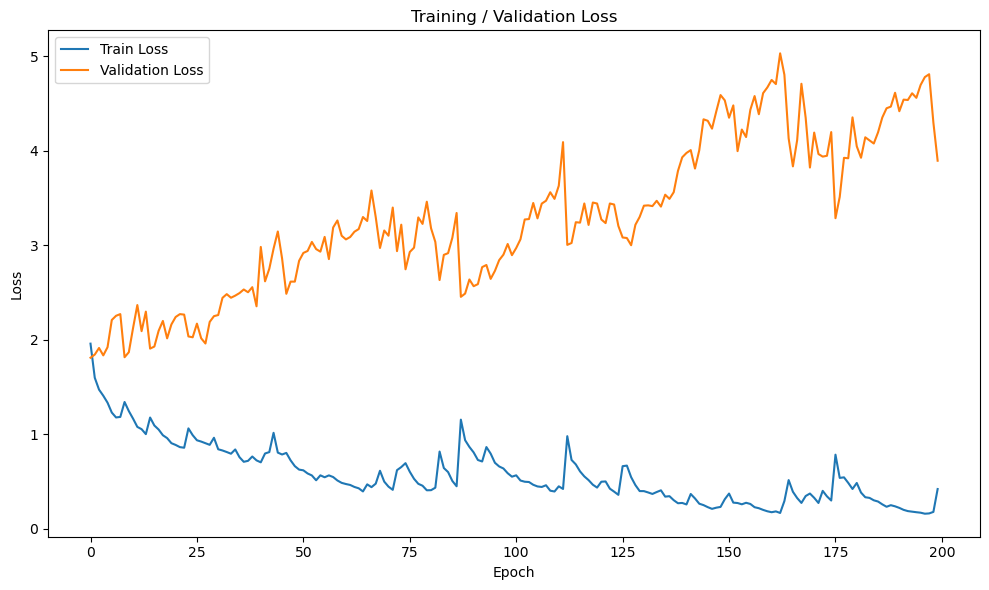

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_loss"], label="Train Loss")
ax.plot(metrics_df["val_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)



## plot loss curves (step train VS step val)

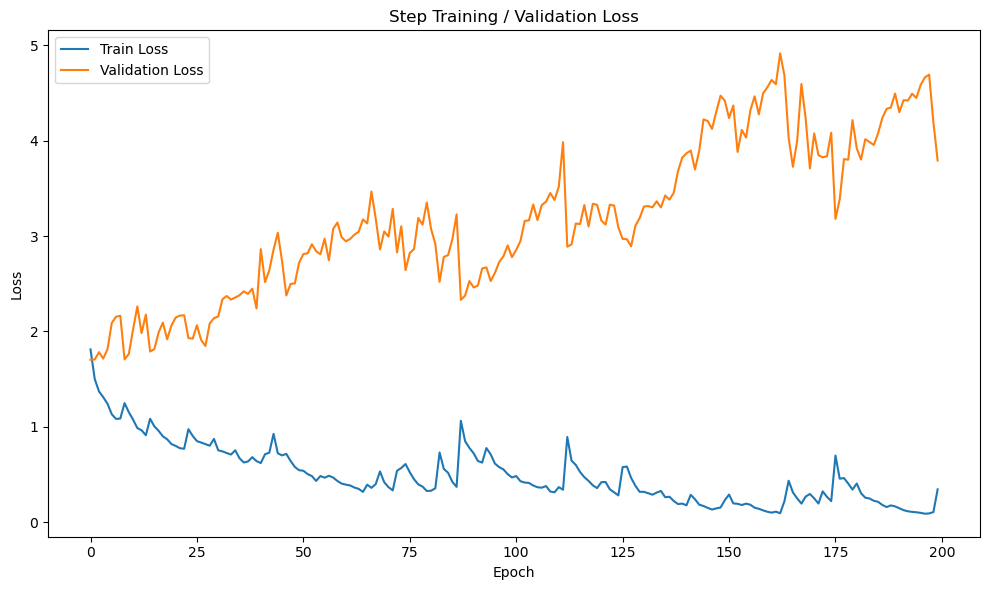

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_step_loss"], label="Train Loss")
ax.plot(metrics_df["val_step_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Step Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "Step_training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

## plot loss curves (progress train VS step val)

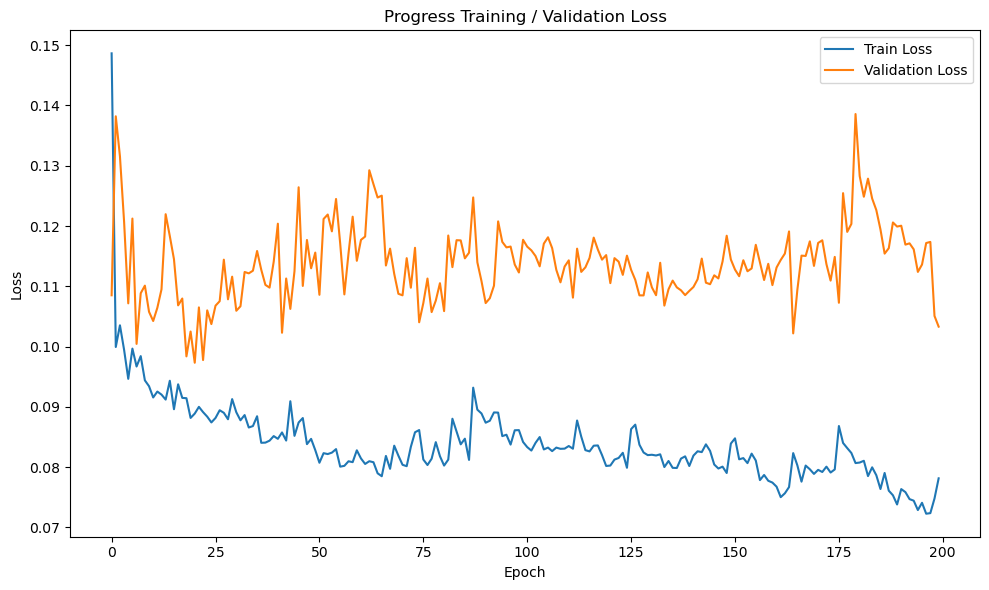

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_progress_loss"], label="Train Loss")
ax.plot(metrics_df["val_progress_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Progress Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "Progress_training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

In [ ]:
import json
best_model_config = best_model_path_dir / "config.json"
best_model_config = json.loads(best_model_config.read_text())
input_dim = best_model_config["input_dim"]
hidden_dim = best_model_config["hidden_dim"]
num_steps = best_model_config["num_steps"]
num_layers = best_model_config.get("num_layers", 1)
dropout = best_model_config.get("dropout", 0.0)
num_mistakes = best_model_config["num_mistakes"]
lambda_mistake = best_model_config["lambda_mistake"]


In [ ]:
model_eval = AssistLSTM(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_steps=num_steps,
    dropout=dropout,
    num_layers=num_layers,
    num_mistakes=num_mistakes
).to(device)

model_eval.load_state_dict(torch.load(best_model_path, map_location=device))

model_eval.eval()

In [ ]:
import pandas as pd
import json

total_loss = 0.0
total_step_loss = 0.0
total_mistake_loss = 0.0
total_mistake_correct = 0
total_progress_loss = 0.0
total_progress_mae = 0.0

total_correct = 0
total_samples = 0

all_rows = []

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_loader):
        x = x.to(device)
        y_step = y["step"].to(device)
        y_progress = y["progress"].to(device)
        y_mistake = y["mistake"].to(device)

        step_logits, progress_pred, mistake_pred = model_eval(x)

        loss_step = ce_loss(step_logits, y_step)
        loss_progress = mse_loss(progress_pred, y_progress)
        loss_mistake = ce_loss(mistake_pred, y_mistake)
        loss = lambda_step * loss_step + lambda_progress * loss_progress + lambda_mistake * loss_mistake

        preds_mistake = mistake_pred.argmax(dim=1)
        preds_step = torch.argmax(step_logits, dim=1)
        progress_mae = torch.mean(torch.abs(progress_pred - y_progress))

        batch_size = x.size(0)

        total_loss += loss.item()
        total_step_loss += loss_step.item()
        total_progress_loss += loss_progress.item()
        total_mistake_loss += loss_mistake.item()
        total_mistake_correct += (preds_mistake == y_mistake).sum().item()
        total_progress_mae += progress_mae.item()

        total_correct += (preds_step == y_step).sum().item()
        total_samples += batch_size

        # save predictions
        for i in range(batch_size):
            all_rows.append({
                "batch_idx": batch_idx,
                "sample_idx_in_batch": i,
                "true_mistake": int(y_mistake[i].cpu().item()),
                "pred_mistake": int(preds_mistake[i].cpu().item()),
                "true_step": int(y_step[i].cpu().item()),
                "pred_step": int(preds_step[i].cpu().item()),
                "true_progress": float(y_progress[i].cpu().item()),
                "pred_progress": float(progress_pred[i].cpu().item()),
                "progress_abs_error": float(
                    torch.abs(progress_pred[i] - y_progress[i]).cpu().item()
                ),
            })

test_loss = total_loss / len(test_loader)
test_step_loss = total_step_loss / len(test_loader)
test_progress_loss = total_progress_loss / len(test_loader)
test_progress_mae = total_progress_mae / len(test_loader)
test_acc = total_correct / total_samples
test_mistake_loss = total_mistake_loss / len(test_loader)
test_mistake_acc = total_mistake_correct / total_samples

results = {
    "test_loss": test_loss,
    "test_step_loss": test_step_loss,
    "test_progress_loss": test_progress_loss,
    "test_acc": test_acc,
    "test_mistake_loss": test_mistake_loss,
    "test_mistake_acc": test_mistake_acc,
    "test_progress_mae": test_progress_mae,
    "test_progress_mae_percent": test_progress_mae * 100,
}

pred_df = pd.DataFrame(all_rows)

In [30]:
pred_df.to_csv(best_model_path_dir / "test_predictions.csv", index=False)

with open(best_model_path_dir / "test_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Saved test predictions and results.")

Saved test predictions and results.


### Step prediction

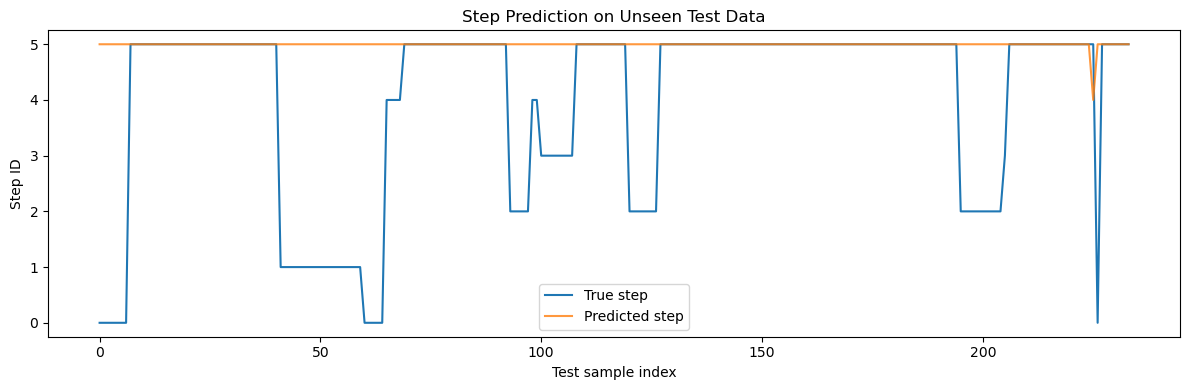

In [31]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(pred_df["true_step"].values, label="True step")
ax.plot(pred_df["pred_step"].values, label="Predicted step", alpha=0.8)

ax.set_xlabel("Test sample index")
ax.set_ylabel("Step ID")
ax.set_title("Step Prediction on Unseen Test Data")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "step_prediction_plot.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

### Progress prediction & error

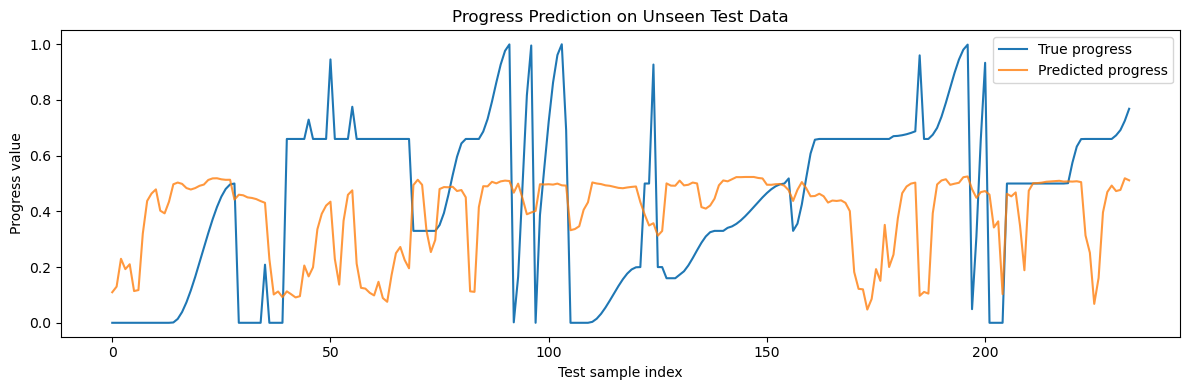

In [32]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pred_df["true_progress"].values, label="True progress")
ax.plot(pred_df["pred_progress"].values, label="Predicted progress", alpha=0.8)

ax.set_xlabel("Test sample index")
ax.set_ylabel("Progress value")

ax.set_title("Progress Prediction on Unseen Test Data")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "progress_prediction_plot.png", dpi=200, bbox_inches="tight")
plt.show()  
plt.close(fig)

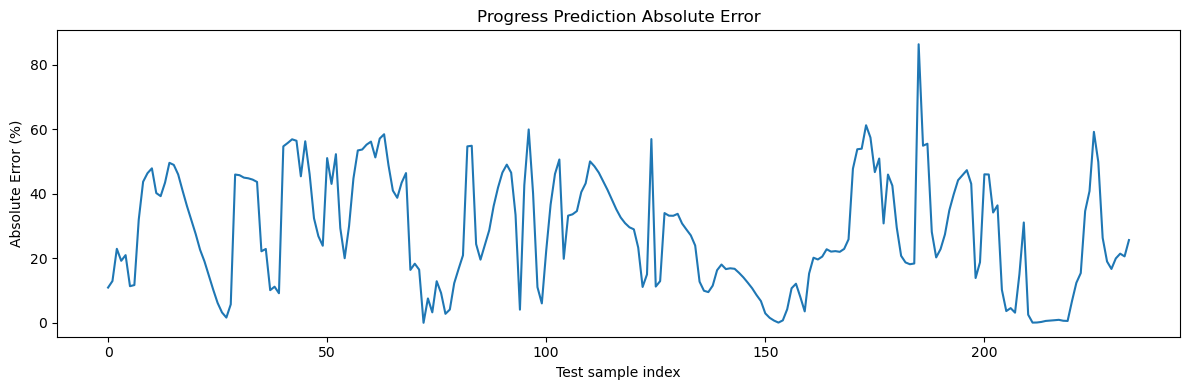

In [33]:
fig, ax  = plt.subplots(figsize=(12, 4))
ax.plot(pred_df["progress_abs_error"].values * 100, label="Absolute Error")
ax.set_xlabel("Test sample index")
ax.set_ylabel("Absolute Error (%)") 

ax.set_title("Progress Prediction Absolute Error")
fig.tight_layout()  
fig.savefig(best_model_path_dir / "progress_prediction_abs_error_plot.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

### step confusion

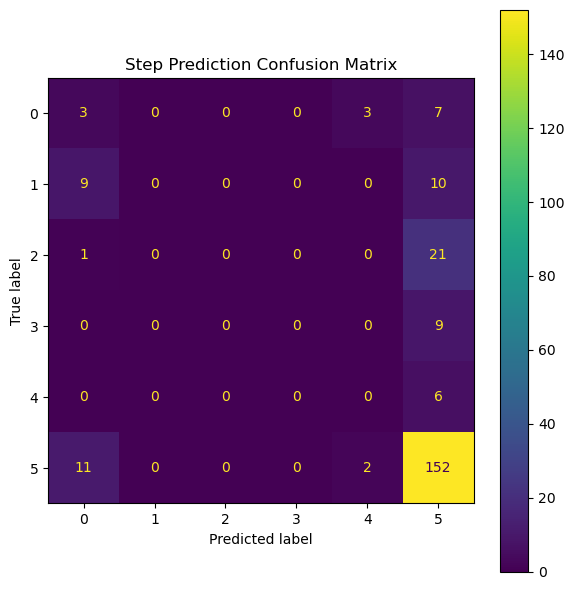

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    pred_df["true_step"],
    pred_df["pred_step"]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=None, ax=ax)

ax.set_title("Step Prediction Confusion Matrix")
fig.tight_layout()

fig.savefig(
    best_model_path_dir / "step_prediction_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

### classification report

In [33]:
from sklearn.metrics import classification_report

print(
    classification_report(
        pred_df["true_step"],
        pred_df["pred_step"],
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.4706    0.6154    0.5333        13
           1     0.0000    0.0000    0.0000        19
           2     0.2000    0.0455    0.0741        22
           3     0.0000    0.0000    0.0000         9
           4     0.1818    1.0000    0.3077         6
           5     0.7748    0.7091    0.7405       165

    accuracy                         0.5641       234
   macro avg     0.2712    0.3950    0.2759       234
weighted avg     0.5960    0.5641    0.5666       234

